# Import libraries

In [32]:
import numpy as np
import xarray as xr
import xskillscore as xs
import matplotlib.pyplot as plt
import dill

# Upload file pickle

In [33]:
with open('cnn_obs.pkl', 'rb') as file:
    hadisst_dic = dill.load(file)
    ncep_ncar_dic = dill.load(file)

In [34]:
with open('ensemble_prediction.pkl', 'rb') as file:
    results_per_leadtime_testing = dill.load(file)

# Plot

In [ ]:
# Define y_test
y_test = hadisst_dic['SON (di west-east)']['dipole index testing'].fillna(0)

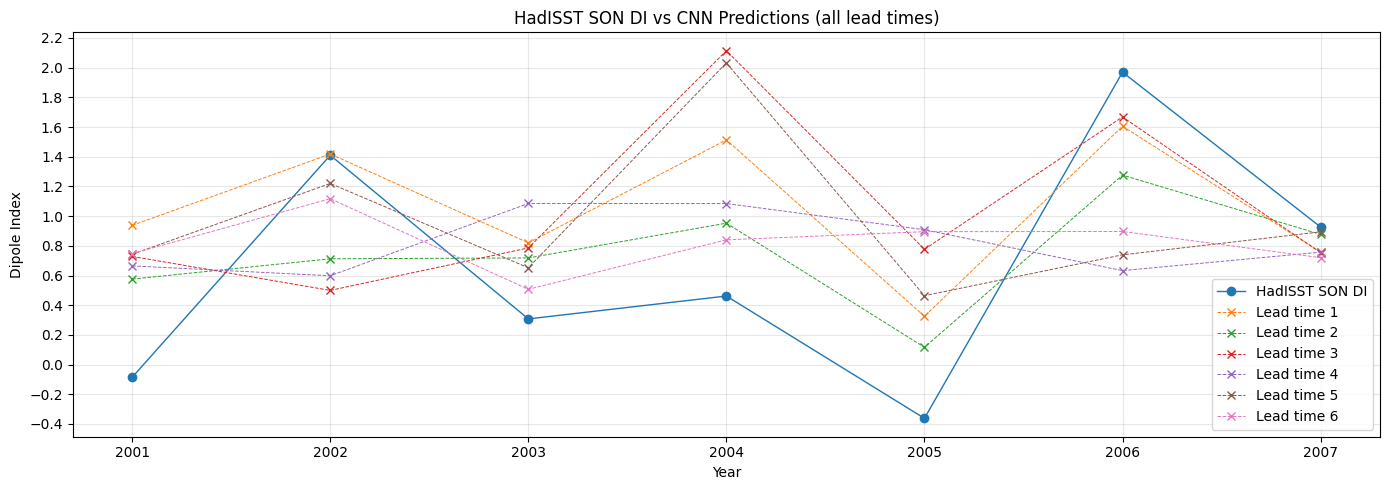

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.time, y_test, color='C0', marker='o', label='HadISST SON DI', linewidth=1)

# Define the color list for each lead time
color_list = ['C1','C2','C3','C4','C5','C6']
for i in range(len(results_per_leadtime_testing)):
    ax.plot(y_test.time, results_per_leadtime_testing[i+1]['ensemble_prediction'], color=color_list[i], marker='x', linestyle='--',lw=0.7,label=f'Lead time {i+1}')

ax.set_xticks(y_test.time.values)
ax.set_yticks(np.arange(-0.4,2.4,0.2))
ax.set_xlabel('Year')
ax.set_ylabel('Dipole Index')
ax.set_title('HadISST SON DI vs CNN Predictions (all lead times)')
ax.legend(loc='best')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

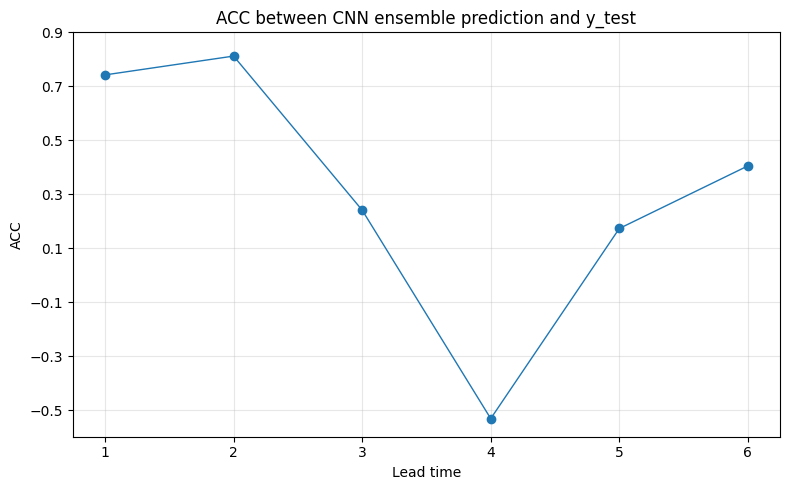

In [43]:
acc_values = []
for i in range(len(results_per_leadtime_testing)):
    pred = results_per_leadtime_testing[i+1]['ensemble_prediction']
    acc = xs.pearson_r(pred, y_test, dim='time').values
    acc_values.append(acc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1,len(results_per_leadtime_testing)+1), acc_values, marker='o', color='C0', linewidth=1)
ax.set_xlabel('Lead time')
ax.set_ylabel('ACC')
ax.set_title('ACC between CNN ensemble prediction and y_test')
ax.set_xticks(np.arange(1,len(results_per_leadtime_testing)+1))
ax.set_yticks(np.arange(-0.5,1.0,0.2))
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()